# Griffiths' product rules (p.21), proved with SymPy
Griffiths lists **six** product rules -- two for gradients, two for divergences, two for
curls -- and says *the proofs come straight from the product rule for ordinary
derivatives.* Let's actually do that: build `grad`, `div`, `curl` from `d/dx`, feed in
**abstract** fields `f, g, A, B` (arbitrary functions, not specific ones), and show each
identity collapses to `0`. Abstract fields => these are genuine proofs, not spot checks.

Then a **chain-rule loop** over integer powers, the photonics phase factor `e^{ix}`, and
a **Bessel** identity that is itself just product-rule + chain-rule (Bessel functions are
the radial fiber modes -- see `dgs/bessel_separation`, `dgs/bessel_fm`).

In [1]:
import sympy as sp
sp.init_printing()
x, y, z = sp.symbols("x y z", real=True)

# the three operators, built from ordinary partial derivatives
def grad(f):  return [sp.diff(f, v) for v in (x, y, z)]
def div(A):   return sum(sp.diff(A[i], v) for i, v in enumerate((x, y, z)))
def curl(A):  return [sp.diff(A[2], y) - sp.diff(A[1], z),
                      sp.diff(A[0], z) - sp.diff(A[2], x),
                      sp.diff(A[1], x) - sp.diff(A[0], y)]
def dot(A, B):   return sum(a*b for a, b in zip(A, B))
def cross(A, B): return [A[1]*B[2]-A[2]*B[1], A[2]*B[0]-A[0]*B[2], A[0]*B[1]-A[1]*B[0]]
def smul(s, A):  return [s*a for a in A]          # scalar times vector

# abstract fields: arbitrary scalar f,g and vector A,B  -> proofs, not examples
f = sp.Function("f")(x, y, z)
g = sp.Function("g")(x, y, z)
A = [sp.Function("A_x")(x, y, z), sp.Function("A_y")(x, y, z), sp.Function("A_z")(x, y, z)]
B = [sp.Function("B_x")(x, y, z), sp.Function("B_y")(x, y, z), sp.Function("B_z")(x, y, z)]

def is_zero_vec(V): return all(sp.simplify(c) == 0 for c in V)
print("operators ready; fields are arbitrary functions, so a 0 below is a real proof")

operators ready; fields are arbitrary functions, so a 0 below is a real proof


## Rule (i) -- gradient of a product:  $\nabla(fg) = f\,\nabla g + g\,\nabla f$
Just the ordinary product rule applied component by component.

In [2]:
lhs = grad(f*g)
rhs = [a + b for a, b in zip(smul(f, grad(g)), smul(g, grad(f)))]
print("grad(f g) - [f grad g + g grad f] =", [sp.simplify(a-b) for a, b in zip(lhs, rhs)])
print("rule (i) holds:", is_zero_vec([a-b for a, b in zip(lhs, rhs)]))

grad(f g) - [f grad g + g grad f] = [0, 0, 0]
rule (i) holds: True


## Rule (iii) -- divergence of (scalar x vector):  $\nabla\cdot(f\mathbf A)=f(\nabla\cdot\mathbf A)+\mathbf A\cdot(\nabla f)$
This is the one Griffiths works out in the text. Each term `d/dx(f A_x)=f dA_x/dx + A_x df/dx`.

In [3]:
lhs = div(smul(f, A))
rhs = f*div(A) + dot(A, grad(f))
print("div(f A) - [f divA + A.grad f] =", sp.simplify(lhs - rhs))
print("rule (iii) holds:", sp.simplify(lhs - rhs) == 0)

div(f A) - [f divA + A.grad f] = 0
rule (iii) holds: True


## Rule (iv) -- divergence of a cross product:  $\nabla\cdot(\mathbf A\times\mathbf B)=\mathbf B\cdot(\nabla\times\mathbf A)-\mathbf A\cdot(\nabla\times\mathbf B)$
The one behind **Poynting's theorem** (`griffiths/vector_identities.py`): with
`A=E, B=B` it turns `div(E x B)` into curl terms = the energy-flow bookkeeping.

In [4]:
lhs = div(cross(A, B))
rhs = dot(B, curl(A)) - dot(A, curl(B))
print("div(A x B) - [B.curlA - A.curlB] =", sp.simplify(lhs - rhs))
print("rule (iv) holds:", sp.simplify(lhs - rhs) == 0)

div(A x B) - [B.curlA - A.curlB] = 0
rule (iv) holds: True


## Rule (vi) -- curl of a cross product (the long one)
$\nabla\times(\mathbf A\times\mathbf B)=(\mathbf B\cdot\nabla)\mathbf A-(\mathbf A\cdot\nabla)\mathbf B+\mathbf A(\nabla\cdot\mathbf B)-\mathbf B(\nabla\cdot\mathbf A)$.
Four terms, easy to slip on by hand -- SymPy confirms it in one shot.

In [5]:
def Adotgrad(A, V):   # (A . grad) V , a directional derivative of each component
    return [A[0]*sp.diff(c, x) + A[1]*sp.diff(c, y) + A[2]*sp.diff(c, z) for c in V]
lhs = curl(cross(A, B))
rhs = [a - b + c - d for a, b, c, d in zip(
        Adotgrad(B, A), Adotgrad(A, B), smul(div(B), A), smul(div(A), B))]
print("rule (vi) holds:", is_zero_vec([a-b for a, b in zip(lhs, rhs)]))

rule (vi) holds: True


## The chain rule, looped over algebraic integers
Every rule above descends from `d/dx`. The **chain rule** is the other half: for the
phase factor `e^{i g(x)}` with `g(x)=x^n`,
$$\frac{d}{dx}e^{i x^n} = i\,n x^{n-1}\,e^{i x^n}.$$
Loop the integer power `n` and check the closed form each time.

In [6]:
for n in range(1, 7):
    g = x**n
    lhs = sp.diff(sp.exp(sp.I*g), x)
    rhs = sp.I*sp.diff(g, x)*sp.exp(sp.I*g)          # i * g'(x) * e^{i g}
    print(f"n={n}:  d/dx e^(i x^{n}) = i*{sp.diff(g,x)}*e^(i x^{n})   match:",
          sp.simplify(lhs - rhs) == 0)

n=1:  d/dx e^(i x^1) = i*1*e^(i x^1)   match: True
n=2:  d/dx e^(i x^2) = i*2*x*e^(i x^2)   match: True
n=3:  d/dx e^(i x^3) = i*3*x**2*e^(i x^3)   match: True
n=4:  d/dx e^(i x^4) = i*4*x**3*e^(i x^4)   match: True
n=5:  d/dx e^(i x^5) = i*5*x**4*e^(i x^5)   match: True
n=6:  d/dx e^(i x^6) = i*6*x**5*e^(i x^6)   match: True


## The photonics phase factor $e^{ix}$ -- and why phase retrieval is hard
`e^{ix} = cos x + i sin x` (Euler). Two facts that *are* the whole phase-retrieval
problem: its derivative just rotates it (`d/dx = i e^{ix}`), and its **magnitude is 1
for every x**. A detector measures `|field|^2`, so it sees `|e^{i phi}|^2 = 1` and the
phase `phi` vanishes -- exactly the information dispersion-GS has to claw back.

In [7]:
print("Euler:    e^(ix) =", sp.exp(sp.I*x).rewrite(sp.cos))
print("derivative: d/dx e^(ix) =", sp.diff(sp.exp(sp.I*x), x), " (= i * e^(ix), pure rotation)")
print("magnitude:  |e^(ix)| =", sp.Abs(sp.exp(sp.I*x)), " for real x  -> phase is invisible to |.|^2")

Euler:    e^(ix) = I*sin(x) + cos(x)
derivative: d/dx e^(ix) = I*exp(I*x)  (= i * e^(ix), pure rotation)
magnitude:  |e^(ix)| = 1  for real x  -> phase is invisible to |.|^2


## A Bessel identity from photonics -- product rule + chain rule together
Bessel functions $J_n$ are the radial modes of a step-index fiber and the FM/PM sideband
amplitudes (`dgs/bessel_separation`, `dgs/bessel_fm`). One of their defining identities
is pure product-rule + chain-rule:
$$\frac{d}{dx}\!\left[x^{\,n} J_n(x)\right] = x^{\,n} J_{n-1}(x).$$
SymPy knows `J_n` and its derivative, so we can verify it symbolically.

In [8]:
n_sym = sp.symbols("n")
for nv in (1, 2, 3):
    lhs = sp.diff(x**nv * sp.besselj(nv, x), x)
    rhs = x**nv * sp.besselj(nv-1, x)
    print(f"n={nv}:  d/dx[x^{nv} J_{nv}(x)] = x^{nv} J_{nv-1}(x)   match:",
          sp.simplify(lhs - rhs) == 0)

n=1:  d/dx[x^1 J_1(x)] = x^1 J_0(x)   match: True
n=2:  d/dx[x^2 J_2(x)] = x^2 J_1(x)   match: True
n=3:  d/dx[x^3 J_3(x)] = x^3 J_2(x)   match: True


And a picture of the first few -- the fiber's radial mode shapes.

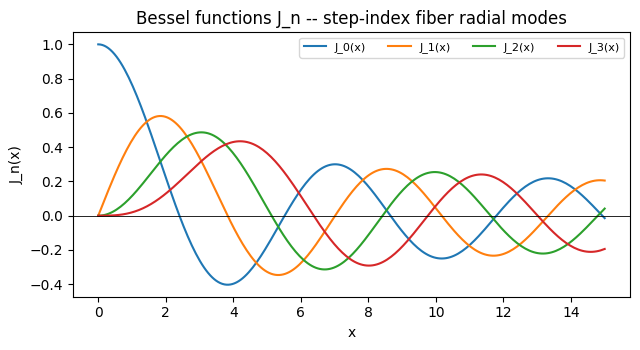

J_0 starts at 1 (the fundamental); higher orders start flat at 0 -- exactly the
radial intensity profiles of LP modes in the core.


In [9]:
import numpy as np, mpmath, matplotlib.pyplot as plt
xs = np.linspace(0, 15, 250)
plt.figure(figsize=(6.5, 3.6))
for nv in (0, 1, 2, 3):
    Jn = [float(mpmath.besselj(nv, t)) for t in xs]
    plt.plot(xs, Jn, label=f"J_{nv}(x)")
plt.axhline(0, color="k", lw=0.6); plt.legend(ncol=4, fontsize=8)
plt.title("Bessel functions J_n -- step-index fiber radial modes")
plt.xlabel("x"); plt.ylabel("J_n(x)"); plt.tight_layout(); plt.show()
print("J_0 starts at 1 (the fundamental); higher orders start flat at 0 -- exactly the")
print("radial intensity profiles of LP modes in the core.")

## Takeaway
- All **six** product rules (and the quotient rules) are the ordinary `d/dx` product rule
  wearing `grad`/`div`/`curl` clothing -- SymPy with abstract fields proves them flat.
- Rule (iv) is the seed of **Poynting's theorem**; rule (i)/(iii) you'll use building
  potentials in Ch.2-3.
- The **chain rule** drives `e^{ix}` (the invisible phase the detector throws away) and
  the **Bessel** recurrences (the fiber's radial modes) -- the same calculus runs from
  Griffiths' front cover straight into the photonics of this project.